<a href="https://colab.research.google.com/github/shubhamanerao9075/General-CPP/blob/main/Crop_and_fertilizer_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Crop and fertilizer dataset.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nStatistics:")
print(df.describe(include="all"))

Shape: (4513, 11)

Columns:
Index(['District_Name', 'Soil_color', 'Nitrogen', 'Phosphorus', 'Potassium',
       'pH', 'Rainfall', 'Temperature', 'Crop', 'Fertilizer', 'Link'],
      dtype='object')

Missing values:
District_Name    0
Soil_color       0
Nitrogen         0
Phosphorus       0
Potassium        0
pH               0
Rainfall         0
Temperature      0
Crop             0
Fertilizer       0
Link             0
dtype: int64

Duplicates: 0

Data types:
District_Name     object
Soil_color        object
Nitrogen           int64
Phosphorus         int64
Potassium          int64
pH               float64
Rainfall           int64
Temperature        int64
Crop              object
Fertilizer        object
Link              object
dtype: object

First 5 rows:
  District_Name Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  \
0      Kolhapur      Black        75          50        100  6.5      1000   
1      Kolhapur      Black        80          50        100  6.5      1000 

In [ ]:
print("Crop distribution:")
print(df["Crop"].value_counts())

print("\nFertilizer distribution:")
print(df["Fertilizer"].value_counts())

print("\nDistrict distribution:")
print(df["District_Name"].value_counts())

print("\nSoil color distribution:")
print(df["Soil_color"].value_counts())

Crop distribution:
Crop
Sugarcane    1010
Wheat         859
Cotton        650
Jowar         394
Maize         350
Rice          309
Groundnut     177
Tur           126
Grapes        125
Ginger        125
Urad           99
Moong          99
Gram           78
Turmeric       55
Soybean        45
Masoor         12
Name: count, dtype: int64

Fertilizer distribution:
Fertilizer
Urea                      1364
DAP                        667
MOP                        571
19:19:19 NPK               480
SSP                        417
Magnesium Sulphate         215
10:26:26 NPK               156
50:26:26 NPK               124
Chilated Micronutrient     108
12:32:16 NPK               106
Ferrous Sulphate            68
13:32:26 NPK                66
Ammonium Sulphate           50
10:10:10 NPK                50
Hydrated Lime               25
White Potash                19
20:20:20 NPK                15
18:46:00 NPK                 6
Sulphur                      6
Name: count, dtype: int64

District 

In [ ]:
df["District_Name"] = df["District_Name"].str.strip()
df["Soil_color"] = df["Soil_color"].str.strip()
df["Crop"] = df["Crop"].str.strip()
df["Fertilizer"] = df["Fertilizer"].str.strip()

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df["Soil_color"].value_counts())

District_Name    0
Soil_color       0
Nitrogen         0
Phosphorus       0
Potassium        0
pH               0
Rainfall         0
Temperature      0
Crop             0
Fertilizer       0
Link             0
dtype: int64
0
Soil_color
Black            2260
Red              1224
Dark Brown        659
Reddish Brown     265
Light Brown        54
Medium Brown       51
Name: count, dtype: int64


In [ ]:
X = df[
    ["District_Name", "Soil_color", "Nitrogen",
     "Phosphorus", "Potassium", "pH",
     "Rainfall", "Temperature"]
]

In [ ]:
y = df["Crop"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3610, 8)
(903, 8)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["District_Name", "Soil_color"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(3610, 17)
(903, 17)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_encoded, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
crop_model = model
crop_preprocessor = preprocessor

print("Crop model saved:", type(crop_model))
print("Crop model features:", crop_model.n_features_in_)

Crop model saved: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Crop model features: 17


In [ ]:
y_pred = model.predict(X_test_encoded)

print(y_pred[:10])

['Cotton' 'Moong' 'Gram' 'Jowar' 'Wheat' 'Sugarcane' 'Sugarcane' 'Wheat'
 'Rice' 'Cotton']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9977851605758582
Accuracy (%): 99.77851605758582


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Cotton       1.00      1.00      1.00       130
      Ginger       1.00      1.00      1.00        25
        Gram       1.00      0.88      0.93        16
      Grapes       1.00      1.00      1.00        25
   Groundnut       1.00      1.00      1.00        35
       Jowar       0.98      1.00      0.99        79
       Maize       1.00      1.00      1.00        70
      Masoor       1.00      1.00      1.00         2
       Moong       1.00      1.00      1.00        20
        Rice       1.00      1.00      1.00        62
     Soybean       1.00      1.00      1.00         9
   Sugarcane       1.00      1.00      1.00       202
         Tur       1.00      1.00      1.00        25
    Turmeric       1.00      1.00      1.00        11
        Urad       1.00      1.00      1.00        20
       Wheat       1.00      1.00      1.00       172

    accuracy                           1.00       903
   macro avg       1.00   

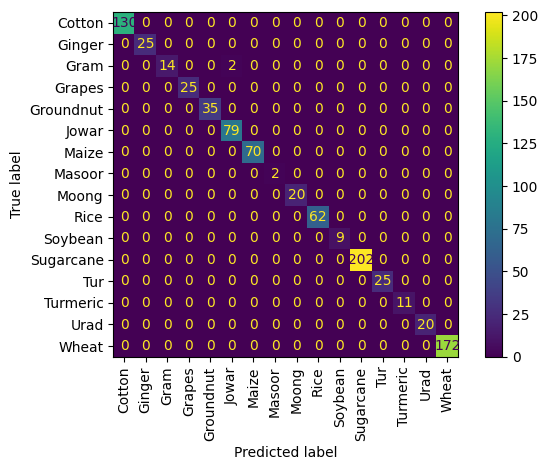

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Save Dataset 1 model and preprocessing
crop_model = model
crop_preprocessor = preprocessor

print("Dataset 1 model and preprocessor saved.")

Dataset 1 model and preprocessor saved.


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                          Feature  Importance
13           remainder__Potassium    0.179532
11            remainder__Nitrogen    0.176759
15            remainder__Rainfall    0.124156
12          remainder__Phosphorus    0.089850
9             cat__Soil_color_Red    0.064212
16         remainder__Temperature    0.062836
0     cat__District_Name_Kolhapur    0.050971
6      cat__Soil_color_Dark Brown    0.044744
3       cat__District_Name_Satara    0.039563
5           cat__Soil_color_Black    0.037497
2       cat__District_Name_Sangli    0.034160
4      cat__District_Name_Solapur    0.031325
14                  remainder__pH    0.027920
1         cat__District_Name_Pune    0.012062
10  cat__Soil_color_Reddish Brown    0.011257
8    cat__Soil_color_Medium Brown    0.008170
7     cat__Soil_color_Light Brown    0.004987


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Mean accuracy (%):", scores.mean() * 100)

Cross-validation scores: [0.99722992 0.99584488 0.99861496 0.99445983 0.99722992]
Mean accuracy: 0.9966759002770085
Mean accuracy (%): 99.66759002770085


In [ ]:
import pandas as pd

df = pd.read_csv("/content/cropdata_updated.csv")

print(df.shape)
print(df.head())
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

(16411, 7)
  crop ID   soil_type Seedling Stage  MOI  temp  humidity  result
0   Wheat  Black Soil    Germination    1    25      80.0       1
1   Wheat  Black Soil    Germination    2    26      77.0       1
2   Wheat  Black Soil    Germination    3    27      74.0       1
3   Wheat  Black Soil    Germination    4    28      71.0       1
4   Wheat  Black Soil    Germination    5    29      68.0       1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB
None

Missing va

In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape after removing duplicates: (16283, 7)
Duplicates: 0


In [ ]:
print("\nResult distribution:")
print(df["result"].value_counts())

print("\nResult percentage:")
print(df["result"].value_counts(normalize=True) * 100)


Result distribution:
result
0    8934
1    6227
2    1122
Name: count, dtype: int64

Result percentage:
result
0    54.867039
1    38.242339
2     6.890622
Name: proportion, dtype: float64


In [ ]:
X = df[[
    "crop ID",
    "soil_type",
    "Seedling Stage",
    "MOI",
    "temp",
    "humidity"
]]

y = df["result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16283, 6)
y shape: (16283,)


In [ ]:
X = pd.get_dummies(
    X,
    columns=["crop ID", "soil_type", "Seedling Stage"],
    drop_first=True
)

print("Encoded X shape:", X.shape)

Encoded X shape: (16283, 20)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (13026, 20)
Testing shape: (3257, 20)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[1 1 0 0 0 0 1 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9917101627264354
Accuracy (%): 99.17101627264354

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1787
           1       0.99      1.00      0.99      1246
           2       0.97      0.91      0.94       224

    accuracy                           0.99      3257
   macro avg       0.99      0.97      0.98      3257
weighted avg       0.99      0.99      0.99      3257



In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("5-Fold Accuracy Scores:")
print(cv_scores)

print("Mean CV Accuracy:", cv_scores.mean())
print("Mean CV Accuracy (%):", cv_scores.mean() * 100)

5-Fold Accuracy Scores:
[0.5634019  0.79889469 0.85630949 0.83691646 0.88636364]
Mean CV Accuracy: 0.7883772354988199
Mean CV Accuracy (%): 78.83772354988199


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                              Feature  Importance
0                                                 MOI    0.352905
1                                                temp    0.296888
2                                            humidity    0.226659
14                         Seedling Stage_Germination    0.021507
18                      Seedling Stage_Seedling Stage    0.014115
6                                       crop ID_Wheat    0.013976
17                         Seedling Stage_Pollination    0.012068
19  Seedling Stage_Vegetative Growth / Root or Tub...    0.009817
3                                      crop ID_Chilli    0.006704
4                                      crop ID_Potato    0.006676
13          Seedling Stage_Fruit/Grain/Bulb Formation    0.005760
5                                      crop ID_Tomato    0.005049
10                                soil_type_Loam Soil    0.004805
9                                 soil_type_Clay Soil    0.004540
16        

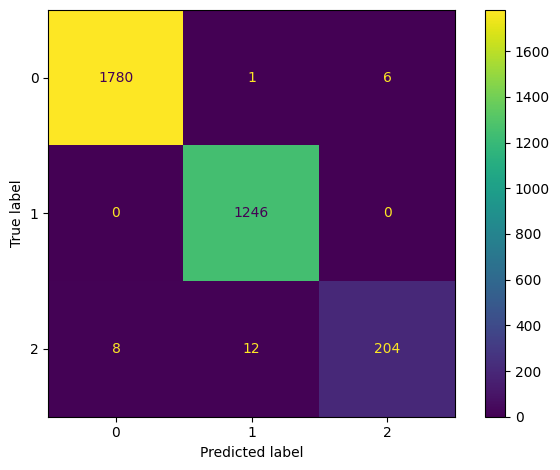

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.tight_layout()
plt.show()

In [ ]:
print("Overall class distribution:")
print(y.value_counts())

print("\nOverall class percentage:")
print(y.value_counts(normalize=True) * 100)

print("\nCross-validation using stratified folds:")

from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print(cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Mean CV Accuracy (%):", cv_scores.mean() * 100)

Overall class distribution:
result
0    8934
1    6227
2    1122
Name: count, dtype: int64

Overall class percentage:
result
0    54.867039
1    38.242339
2     6.890622
Name: proportion, dtype: float64

Cross-validation using stratified folds:
[0.99416641 0.99171016 0.9960086  0.98894349 0.995086  ]
Mean CV Accuracy: 0.993182930886339
Mean CV Accuracy (%): 99.31829308863391


In [ ]:
import pandas as pd

df = pd.read_csv("/content/fertilizer_recommendation.csv")

print(df.shape)
print(df.head())
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

(10000, 20)
  Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0      Clay     6.07          34.98            0.32                     1.87   
1      Silt     6.39          47.34            0.28                     0.21   
2     Sandy     7.92          38.13            0.99                     1.88   
3      Clay     5.86          14.17            1.46                     0.36   
4      Clay     7.98          19.28            0.85                     2.16   

   Nitrogen_Level  Phosphorus_Level  Potassium_Level  Temperature  Humidity  \
0              61                44               84        19.84     83.31   
1              59                56               18        24.40     46.27   
2              43                21              119        24.82     71.86   
3              88                46               34        27.87     53.23   
4             104                53               98        24.17     51.87   

   Rainfall Crop_Type Crop_Growt

In [ ]:
print("Fertilizer distribution:")
print(df["Recommended_Fertilizer"].value_counts())

print("\nFertilizer percentage:")
print(df["Recommended_Fertilizer"].value_counts(normalize=True) * 100)

Fertilizer distribution:
Recommended_Fertilizer
Urea             3101
DAP              2920
MOP              1408
Compost           996
Zinc Sulphate     752
NPK               641
SSP               182
Name: count, dtype: int64

Fertilizer percentage:
Recommended_Fertilizer
Urea             31.01
DAP              29.20
MOP              14.08
Compost           9.96
Zinc Sulphate     7.52
NPK               6.41
SSP               1.82
Name: proportion, dtype: float64


In [ ]:
X = df[[
    "Soil_Type",
    "Soil_pH",
    "Soil_Moisture",
    "Organic_Carbon",
    "Electrical_Conductivity",
    "Nitrogen_Level",
    "Phosphorus_Level",
    "Potassium_Level",
    "Temperature",
    "Humidity",
    "Rainfall",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Previous_Crop",
    "Region",
    "Fertilizer_Used_Last_Season",
    "Yield_Last_Season"
]]

y = df["Recommended_Fertilizer"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget classes:")
print(y.unique())

X shape: (10000, 19)
y shape: (10000,)

Target classes:
['MOP' 'Urea' 'Zinc Sulphate' 'Compost' 'NPK' 'DAP' 'SSP']


In [ ]:
# One-hot encode categorical features

X_encoded = pd.get_dummies(
    X,
    columns=[
        "Soil_Type",
        "Crop_Type",
        "Crop_Growth_Stage",
        "Season",
        "Irrigation_Type",
        "Previous_Crop",
        "Region"
    ],
    drop_first=True
)

print("Encoded X shape:", X_encoded.shape)
print("Target shape:", y.shape)

Encoded X shape: (10000, 39)
Target shape: (10000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 39)
X_test: (2000, 39)
y_train: (8000,)
y_test: (2000,)


In [ ]:
fertilizer_model = model
fertilizer_columns = X.columns.tolist()

print("Fertilizer model:", type(fertilizer_model))
print("Fertilizer features:", fertilizer_model.n_features_in_)

Fertilizer model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Fertilizer features: 20


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [ ]:
# Save Dataset 5 fertilizer model
fertilizer_model = model

# IMPORTANT: save the encoded training columns
fertilizer_columns = X_encoded.columns.tolist()

print("Fertilizer model:", type(fertilizer_model))
print("Fertilizer features:", fertilizer_model.n_features_in_)
print("Saved columns:", len(fertilizer_columns))

Fertilizer model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Fertilizer features: 39
Saved columns: 39


In [ ]:
# Save Dataset 5 model and feature columns
fertilizer_model = model
fertilizer_columns = X.columns.tolist()

print("Dataset 5 model saved.")

Dataset 5 model saved.


In [ ]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
['Compost' 'Urea' 'Zinc Sulphate' 'MOP' 'SSP' 'DAP' 'Urea' 'Zinc Sulphate'
 'MOP' 'MOP']


Accuracy: 0.879
Accuracy (%): 87.9

Classification Report:
               precision    recall  f1-score   support

      Compost       0.81      0.83      0.82       199
          DAP       0.97      0.93      0.95       584
          MOP       0.87      0.86      0.87       282
          NPK       0.76      0.73      0.75       128
          SSP       0.18      0.05      0.08        37
         Urea       0.95      0.95      0.95       620
Zinc Sulphate       0.60      0.83      0.69       150

     accuracy                           0.88      2000
    macro avg       0.74      0.74      0.73      2000
 weighted avg       0.88      0.88      0.88      2000


Confusion Matrix:
[[166   2   3   8   1   5  14]
 [  5 543   7   4   1   4  20]
 [  7   2 243   6   2   6  16]
 [  8   0   4  94   1   7  14]
 [  6   2   8   5   2   4  10]
 [  5   7   7   3   3 586   9]
 [  8   3   6   3   1   5 124]]


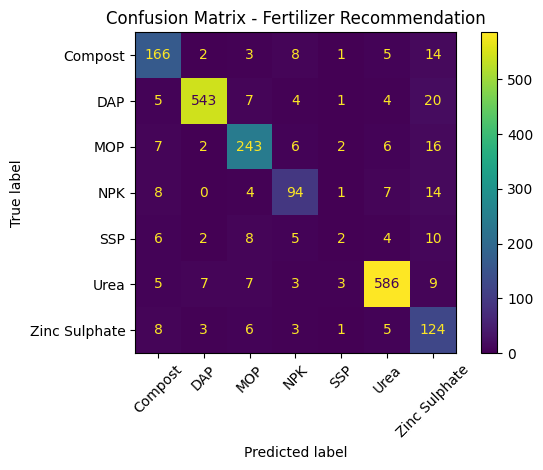


Feature Importance:
                         Feature  Importance
4                 Nitrogen_Level    0.328970
5               Phosphorus_Level    0.226047
6                Potassium_Level    0.095823
0                        Soil_pH    0.091040
8                       Humidity    0.021714
1                  Soil_Moisture    0.021485
7                    Temperature    0.021183
10   Fertilizer_Used_Last_Season    0.020986
9                       Rainfall    0.020953
11             Yield_Last_Season    0.020666
3        Electrical_Conductivity    0.019985
2                 Organic_Carbon    0.019849
23  Crop_Growth_Stage_Vegetative    0.014408
25                   Season_Zaid    0.003756
24                   Season_Rabi    0.003551
21     Crop_Growth_Stage_Harvest    0.003527
28     Irrigation_Type_Sprinkler    0.003272
14                Soil_Type_Silt    0.003270
26          Irrigation_Type_Drip    0.003267
13               Soil_Type_Sandy    0.003172
12               Soil_Type_Loamy  

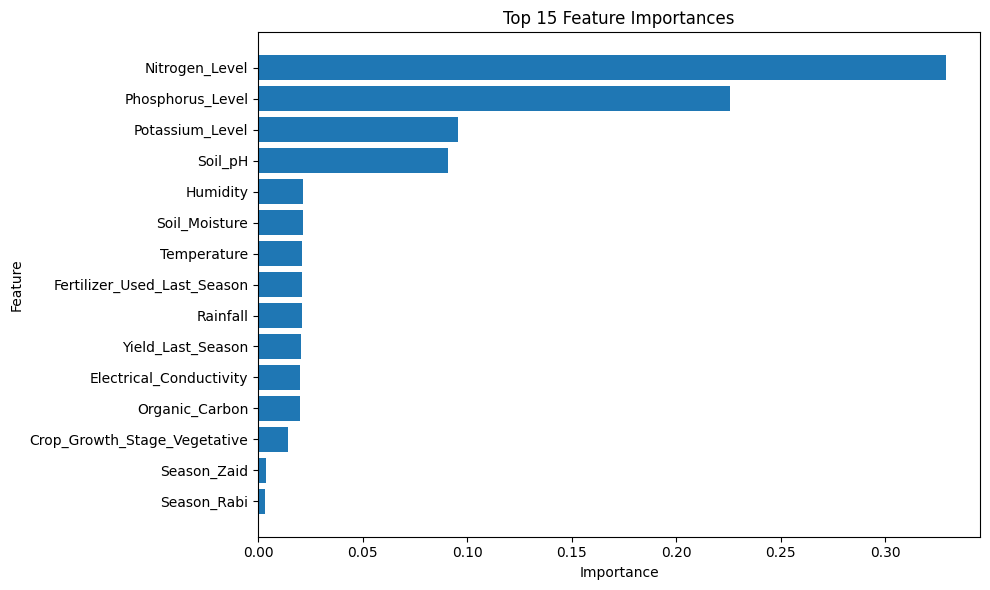


5-Fold Cross Validation Scores:
[0.8795 0.88   0.8845 0.8965 0.8865]

Mean CV Accuracy: 0.8854000000000001
Mean CV Accuracy (%): 88.54
CV Standard Deviation: 0.006151422599691875

========== DATASET 5 SUMMARY ==========
Test Accuracy: 87.9 %
Mean CV Accuracy: 88.54 %
CV Standard Deviation: 0.0062

Top 10 Important Features:
                    Feature  Importance
             Nitrogen_Level    0.328970
           Phosphorus_Level    0.226047
            Potassium_Level    0.095823
                    Soil_pH    0.091040
                   Humidity    0.021714
              Soil_Moisture    0.021485
                Temperature    0.021183
Fertilizer_Used_Last_Season    0.020986
                   Rainfall    0.020953
          Yield_Last_Season    0.020666


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


# ============================================================
# 2. Classification Report
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# 3. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Fertilizer Recommendation")
plt.tight_layout()
plt.show()


# ============================================================
# 4. Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


# Top 15 features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


# ============================================================
# 5. Stratified 5-Fold Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_encoded,
    y,
    cv=skf,
    scoring="accuracy"
)

print("\n5-Fold Cross Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Mean CV Accuracy (%):", cv_scores.mean() * 100)

print("CV Standard Deviation:", cv_scores.std())


# ============================================================
# 6. Final Summary
# ============================================================

print("\n========== DATASET 5 SUMMARY ==========")

print("Test Accuracy:", round(accuracy * 100, 2), "%")
print("Mean CV Accuracy:", round(cv_scores.mean() * 100, 2), "%")
print("CV Standard Deviation:", round(cv_scores.std(), 4))

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [ ]:
# Reload Dataset 5 fresh
fert_df = pd.read_csv("/content/fertilizer_recommendation.csv")

# Features and target
X_fert = fert_df[[
    "Soil_Type",
    "Soil_pH",
    "Soil_Moisture",
    "Organic_Carbon",
    "Electrical_Conductivity",
    "Nitrogen_Level",
    "Phosphorus_Level",
    "Potassium_Level",
    "Temperature",
    "Humidity",
    "Rainfall",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Previous_Crop",
    "Region",
    "Fertilizer_Used_Last_Season",
    "Yield_Last_Season"
]]

y_fert = fert_df["Recommended_Fertilizer"]

# Encode categorical columns
X_fert_encoded = pd.get_dummies(
    X_fert,
    columns=[
        "Soil_Type",
        "Crop_Type",
        "Crop_Growth_Stage",
        "Season",
        "Irrigation_Type",
        "Previous_Crop",
        "Region"
    ],
    drop_first=True
)

print("Encoded fertilizer features:", X_fert_encoded.shape)

Encoded fertilizer features: (10000, 39)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train_fert, X_test_fert, y_train_fert, y_test_fert = train_test_split(
    X_fert_encoded,
    y_fert,
    test_size=0.20,
    random_state=42,
    stratify=y_fert
)

print("Training:", X_train_fert.shape)
print("Testing:", X_test_fert.shape)

fertilizer_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

fertilizer_model.fit(X_train_fert, y_train_fert)
model.fit(X_train, y_train)

# Save Dataset 6 model
irrigation_model = model
irrigation_columns = X_encoded.columns.tolist()

print("Irrigation model:", type(irrigation_model))
print("Irrigation features:", irrigation_model.n_features_in_)
print("Saved columns:", len(irrigation_columns))

fertilizer_columns = X_fert_encoded.columns.tolist()

print("Fertilizer model:", type(fertilizer_model))
print("Fertilizer features:", fertilizer_model.n_features_in_)
print("Saved columns:", len(fertilizer_columns))

Training: (8000, 39)
Testing: (2000, 39)
Irrigation model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Irrigation features: 39
Saved columns: 39
Fertilizer model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Fertilizer features: 39
Saved columns: 39


In [ ]:
# 1. Define the dictionary first
farmer_data = {
    # Location
    "District_Name": "Pune",
    "Region": "Maharashtra",
    "Season": "Kharif",

    # Soil
    "Soil_color": "Black",
    "Soil_Type": "Black Soil",
    "Nitrogen": 80,
    "Phosphorus": 40,
    "Potassium": 40,
    "pH": 6.5,
    "Soil_Moisture": 35,
    "Organic_Carbon": 0.9,
    "Electrical_Conductivity": 1.5,

    # Weather
    "Temperature": 25,
    "Humidity": 70,
    "Rainfall": 800,
    "Sunlight_Hours": 7,
    "Wind_Speed_kmh": 10,

    # Crop
    "Crop_Type": "Wheat",
    "Crop_Growth_Stage": "Vegetative",
    "Previous_Crop": "Rice",

    # Irrigation
    "Irrigation_Type": "Drip",
    "Water_Source": "Groundwater",
    "Field_Area_hectare": 2,
    "Mulching_Used": "Yes",
    "Previous_Irrigation_mm": 50,

    # Farming history
    "Fertilizer_Used_Last_Season": 200,
    "Yield_Last_Season": 25
}

# 2. Then update or access it
farmer_data["Fertilizer_Used_Last_Season"] = 200

In [ ]:
farmer_data["Fertilizer_Used_Last_Season"] = 200

In [ ]:
import pandas as pd

# 1. Predict recommended_crop first using the crop model
crop_input = pd.DataFrame([{
    "District_Name": farmer_data["District_Name"],
    "Soil_color": farmer_data["Soil_color"],
    "Nitrogen": farmer_data["Nitrogen"],
    "Phosphorus": farmer_data["Phosphorus"],
    "Potassium": farmer_data["Potassium"],
    "pH": farmer_data["pH"],
    "Rainfall": farmer_data["Rainfall"],
    "Temperature": farmer_data["Temperature"]
}])

crop_input_encoded = crop_preprocessor.transform(crop_input)
recommended_crop = crop_model.predict(crop_input_encoded)[0]
print("Recommended Crop:", recommended_crop)

# 2. Now build fertilizer_input using the predicted crop
fertilizer_input = pd.DataFrame([{
    "Soil_Type": farmer_data["Soil_Type"],
    "Soil_pH": farmer_data["pH"],
    "Soil_Moisture": farmer_data["Soil_Moisture"],
    "Organic_Carbon": farmer_data["Organic_Carbon"],
    "Electrical_Conductivity": farmer_data["Electrical_Conductivity"],
    "Nitrogen_Level": farmer_data["Nitrogen"],
    "Phosphorus_Level": farmer_data["Phosphorus"],
    "Potassium_Level": farmer_data["Potassium"],
    "Temperature": farmer_data["Temperature"],
    "Humidity": farmer_data["Humidity"],
    "Rainfall": farmer_data["Rainfall"],
    "Crop_Type": recommended_crop,
    "Crop_Growth_Stage": farmer_data["Crop_Growth_Stage"],
    "Season": farmer_data["Season"],
    "Irrigation_Type": farmer_data["Irrigation_Type"],
    "Previous_Crop": farmer_data["Previous_Crop"],
    "Region": farmer_data["Region"],
    "Fertilizer_Used_Last_Season": farmer_data["Fertilizer_Used_Last_Season"],
    "Yield_Last_Season": farmer_data["Yield_Last_Season"]
}])

print(fertilizer_input)

Recommended Crop: Jowar
    Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  Black Soil      6.5             35             0.9   

   Electrical_Conductivity  Nitrogen_Level  Phosphorus_Level  Potassium_Level  \
0                      1.5              80                40               40   

   Temperature  Humidity  Rainfall Crop_Type Crop_Growth_Stage  Season  \
0           25        70       800     Jowar        Vegetative  Kharif   

  Irrigation_Type Previous_Crop       Region  Fertilizer_Used_Last_Season  \
0            Drip          Rice  Maharashtra                          200   

   Yield_Last_Season  
0                 25  


In [ ]:
fertilizer_input = pd.DataFrame([{
    "Soil_Type": farmer_data["Soil_Type"],
    "Soil_pH": farmer_data["pH"],
    "Soil_Moisture": farmer_data["Soil_Moisture"],
    "Organic_Carbon": farmer_data["Organic_Carbon"],
    "Electrical_Conductivity": farmer_data["Electrical_Conductivity"],
    "Nitrogen_Level": farmer_data["Nitrogen"],
    "Phosphorus_Level": farmer_data["Phosphorus"],
    "Potassium_Level": farmer_data["Potassium"],
    "Temperature": farmer_data["Temperature"],
    "Humidity": farmer_data["Humidity"],
    "Rainfall": farmer_data["Rainfall"],
    "Crop_Type": recommended_crop,
    "Crop_Growth_Stage": farmer_data["Crop_Growth_Stage"],
    "Season": farmer_data["Season"],
    "Irrigation_Type": farmer_data["Irrigation_Type"],
    "Previous_Crop": farmer_data["Previous_Crop"],
    "Region": farmer_data["Region"],
    "Fertilizer_Used_Last_Season": farmer_data["Fertilizer_Used_Last_Season"],
    "Yield_Last_Season": farmer_data["Yield_Last_Season"]
}])

print(fertilizer_input)

    Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  Black Soil      6.5             35             0.9   

   Electrical_Conductivity  Nitrogen_Level  Phosphorus_Level  Potassium_Level  \
0                      1.5              80                40               40   

   Temperature  Humidity  Rainfall Crop_Type Crop_Growth_Stage  Season  \
0           25        70       800     Jowar        Vegetative  Kharif   

  Irrigation_Type Previous_Crop       Region  Fertilizer_Used_Last_Season  \
0            Drip          Rice  Maharashtra                          200   

   Yield_Last_Season  
0                 25  


In [ ]:
fertilizer_input_encoded = pd.get_dummies(
    fertilizer_input,
    columns=[
        "Soil_Type",
        "Crop_Type",
        "Crop_Growth_Stage",
        "Season",
        "Irrigation_Type",
        "Previous_Crop",
        "Region"
    ],
    drop_first=True
)

fertilizer_input_encoded = fertilizer_input_encoded.reindex(
    columns=fertilizer_columns,
    fill_value=0
)

recommended_fertilizer = fertilizer_model.predict(
    fertilizer_input_encoded
)[0]

print("Recommended Fertilizer:", recommended_fertilizer)

Recommended Fertilizer: Compost


In [ ]:
# ============================================================
# DATASET 6 - IRRIGATION PREDICTION
# Initial Dataset Inspection
# ============================================================

import pandas as pd

# Load dataset
df6 = pd.read_csv("/content/irrigation_prediction.csv")

# Basic information
print("Dataset Shape:")
print(df6.shape)

print("\nColumn Names:")
print(df6.columns.tolist())

print("\nFirst 5 Rows:")
print(df6.head())

print("\nDataset Information:")
df6.info()

# Missing values
print("\nMissing Values:")
print(df6.isnull().sum())

# Duplicate rows
print("\nNumber of Duplicate Rows:")
print(df6.duplicated().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df6.describe(include="all").T)

Dataset Shape:
(10000, 20)

Column Names:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

First 5 Rows:
  Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0      Clay     6.14          36.48            0.42                     2.17   
1      Silt     6.41          50.56            0.38                     0.23   
2     Sandy     7.71          40.07            1.09                     2.18   
3      Clay     5.96          12.75            1.56                     0.40   
4      Clay     7.76          18.58            0.95                     2.52   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0          21.90     31.19      1167.70        

In [ ]:
print("Irrigation Need Distribution:")
print(df6["Irrigation_Need"].value_counts())

print("\nIrrigation Need Percentage:")
print(df6["Irrigation_Need"].value_counts(normalize=True) * 100)

Irrigation Need Distribution:
Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

Irrigation Need Percentage:
Irrigation_Need
Low       58.64
Medium    38.00
High       3.36
Name: proportion, dtype: float64


X shape: (10000, 19)
y shape: (10000,)

Encoded X shape: (10000, 35)

X_train: (8000, 35)
X_test: (2000, 35)
y_train: (8000,)
y_test: (2000,)

Model training completed.

First 10 predictions:
['Medium' 'Medium' 'Low' 'Medium' 'Medium' 'Low' 'Medium' 'Low' 'Medium'
 'Low']

================ ACCURACY ================
Accuracy: 0.9725
Accuracy (%): 97.25

============= CLASSIFICATION REPORT =============
              precision    recall  f1-score   support

        High       1.00      0.42      0.59        67
         Low       0.99      1.00      0.99      1173
      Medium       0.95      0.98      0.96       760

    accuracy                           0.97      2000
   macro avg       0.98      0.80      0.85      2000
weighted avg       0.97      0.97      0.97      2000


================ CONFUSION MATRIX ================
[[  28    0   39]
 [   0 1172    1]
 [   0   15  745]]


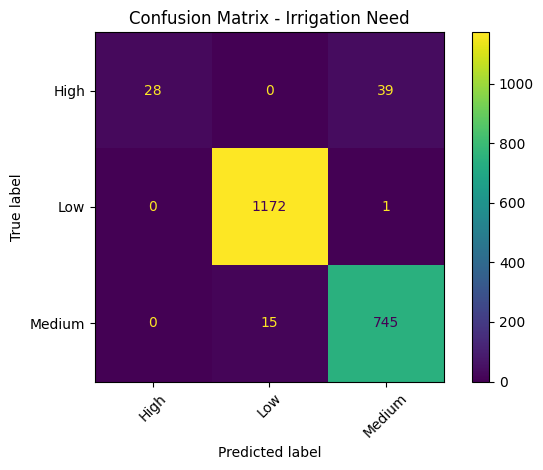


============= FEATURE IMPORTANCE =============
                         Feature  Importance
1                  Soil_Moisture    0.179961
8                 Wind_Speed_kmh    0.093646
4                  Temperature_C    0.091495
6                    Rainfall_mm    0.090991
19     Crop_Growth_Stage_Harvest    0.086407
20      Crop_Growth_Stage_Sowing    0.079453
30             Mulching_Used_Yes    0.072397
21  Crop_Growth_Stage_Vegetative    0.036886
5                       Humidity    0.028626
9             Field_Area_hectare    0.027988
10        Previous_Irrigation_mm    0.027931
7                 Sunlight_Hours    0.027515
0                        Soil_pH    0.027283
3        Electrical_Conductivity    0.026417
2                 Organic_Carbon    0.026339
22                   Season_Rabi    0.004397
23                   Season_Zaid    0.004359
24          Irrigation_Type_Drip    0.004165
28        Water_Source_Reservoir    0.004110
11               Soil_Type_Loamy    0.004069
29     

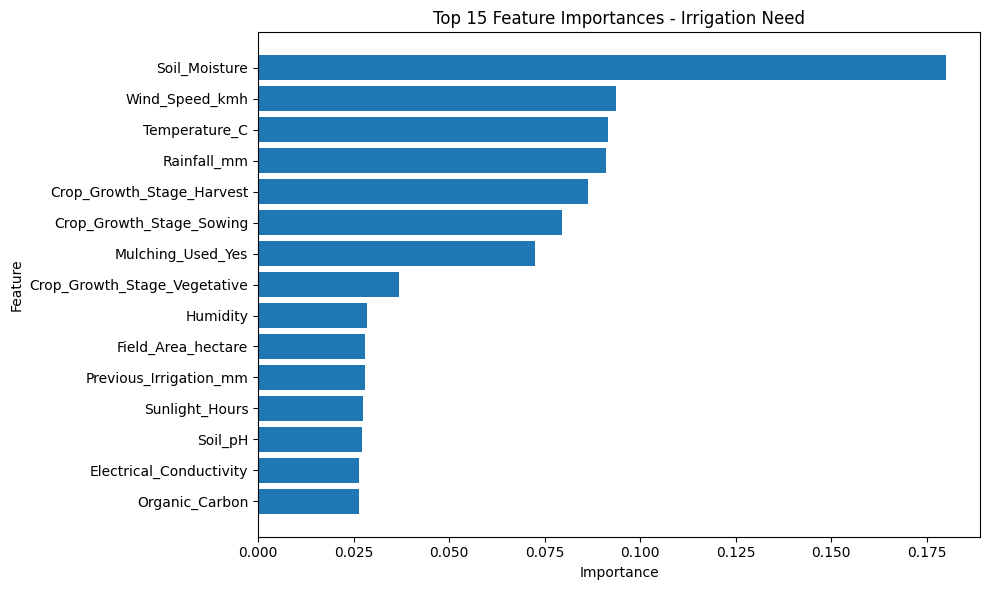


============= 5-FOLD CROSS VALIDATION =============
Fold scores:
[0.9705 0.977  0.971  0.969  0.977 ]

Mean CV Accuracy: 0.9728999999999999
Mean CV Accuracy (%): 97.28999999999999
CV Standard Deviation: 0.003411744421846391

             DATASET 6 FINAL SUMMARY
Dataset size: (10000, 20)
Input features: 19
Encoded features: 35
Number of classes: 3

Test Accuracy: 97.25 %
5-Fold CV Accuracy: 97.29 %
CV Standard Deviation: 0.0034

Irrigation Classes:
['High', 'Low', 'Medium']

Top 10 Important Features:
                     Feature  Importance
               Soil_Moisture    0.179961
              Wind_Speed_kmh    0.093646
               Temperature_C    0.091495
                 Rainfall_mm    0.090991
   Crop_Growth_Stage_Harvest    0.086407
    Crop_Growth_Stage_Sowing    0.079453
           Mulching_Used_Yes    0.072397
Crop_Growth_Stage_Vegetative    0.036886
                    Humidity    0.028626
          Field_Area_hectare    0.027988


In [ ]:
# ============================================================
# DATASET 6 - IRRIGATION NEED PREDICTION
# Random Forest Classification
# ============================================================

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Feature Selection
# ============================================================

X = df6[[
    "Soil_Type",
    "Soil_pH",
    "Soil_Moisture",
    "Organic_Carbon",
    "Electrical_Conductivity",
    "Temperature_C",
    "Humidity",
    "Rainfall_mm",
    "Sunlight_Hours",
    "Wind_Speed_kmh",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Water_Source",
    "Field_Area_hectare",
    "Mulching_Used",
    "Previous_Irrigation_mm",
    "Region"
]]

y = df6["Irrigation_Need"]

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 2. One-Hot Encoding
# ============================================================

categorical_columns = [
    "Soil_Type",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Water_Source",
    "Mulching_Used",
    "Region"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("\nEncoded X shape:", X_encoded.shape)


# ============================================================
# 3. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


# ============================================================
# 4. Random Forest Classifier
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel training completed.")


# ============================================================
# 5. Predictions
# ============================================================

y_pred = model.predict(X_test)

print("\nFirst 10 predictions:")
print(y_pred[:10])


# ============================================================
# 6. Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n================ ACCURACY ================")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


# ============================================================
# 7. Classification Report
# ============================================================

print("\n============= CLASSIFICATION REPORT =============")
print(classification_report(y_test, y_pred))


# ============================================================
# 8. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\n================ CONFUSION MATRIX ================")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Irrigation Need")
plt.tight_layout()
plt.show()


# ============================================================
# 9. Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n============= FEATURE IMPORTANCE =============")
print(feature_importance)


# Top 15 features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Irrigation Need")
plt.tight_layout()
plt.show()


# ============================================================
# 10. Stratified 5-Fold Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_encoded,
    y,
    cv=skf,
    scoring="accuracy"
)

print("\n============= 5-FOLD CROSS VALIDATION =============")

print("Fold scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Mean CV Accuracy (%):", cv_scores.mean() * 100)

print("CV Standard Deviation:", cv_scores.std())


# ============================================================
# 11. Final Summary
# ============================================================

print("\n===================================================")
print("             DATASET 6 FINAL SUMMARY")
print("===================================================")

print("Dataset size:", df6.shape)
print("Input features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])
print("Number of classes:", y.nunique())

print("\nTest Accuracy:", round(accuracy * 100, 2), "%")
print("5-Fold CV Accuracy:", round(cv_scores.mean() * 100, 2), "%")
print("CV Standard Deviation:", round(cv_scores.std(), 4))

print("\nIrrigation Classes:")
print(list(model.classes_))

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [ ]:
# Save Dataset 6 model and feature columns
irrigation_model = model
irrigation_columns = X.columns.tolist()

print("Dataset 6 model saved.")

Dataset 6 model saved.


In [ ]:
import pandas as pd

irr_df = pd.read_csv("/content/irrigation_prediction.csv")

X_irr = irr_df[[
    "Soil_Type",
    "Soil_pH",
    "Soil_Moisture",
    "Organic_Carbon",
    "Electrical_Conductivity",
    "Temperature_C",
    "Humidity",
    "Rainfall_mm",
    "Sunlight_Hours",
    "Wind_Speed_kmh",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Water_Source",
    "Field_Area_hectare",
    "Mulching_Used",
    "Previous_Irrigation_mm",
    "Region"
]]

y_irr = irr_df["Irrigation_Need"]

X_irr_encoded = pd.get_dummies(
    X_irr,
    columns=[
        "Soil_Type",
        "Crop_Type",
        "Crop_Growth_Stage",
        "Season",
        "Irrigation_Type",
        "Water_Source",
        "Mulching_Used",
        "Region"
    ],
    drop_first=True
)

print("Encoded irrigation features:", X_irr_encoded.shape)

Encoded irrigation features: (10000, 35)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train_irr, X_test_irr, y_train_irr, y_test_irr = train_test_split(
    X_irr_encoded,
    y_irr,
    test_size=0.20,
    random_state=42,
    stratify=y_irr
)

print("Irrigation training:", X_train_irr.shape)
print("Irrigation testing:", X_test_irr.shape)

irrigation_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

irrigation_model.fit(X_train_irr, y_train_irr)

irrigation_columns = X_irr_encoded.columns.tolist()

print("Irrigation model:", type(irrigation_model))
print("Irrigation features:", irrigation_model.n_features_in_)
print("Saved columns:", len(irrigation_columns))

Irrigation training: (8000, 35)
Irrigation testing: (2000, 35)
Irrigation model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Irrigation features: 35
Saved columns: 35


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Load dataset
df = pd.read_csv("/content/crop_yield.csv")

print(df.shape)
print(df.head())
print(df.info())


# 2. Check missing values and duplicates
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())


# 3. Clean categorical columns
df["Crop"] = df["Crop"].str.strip()
df["Season"] = df["Season"].str.strip()
df["State"] = df["State"].str.strip()


# 4. Select features and target
X = df[[
    "Crop",
    "Crop_Year",
    "Season",
    "State",
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide"
]]

y = df["Yield"]


# 5. Convert categorical columns into numerical values
X = pd.get_dummies(
    X,
    columns=["Crop", "Season", "State"],
    drop_first=True
)

print("\nEncoded X shape:", X.shape)


# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


# 7. Random Forest Regression
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


# 8. Prediction
y_pred = model.predict(X_test)


# 9. Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", mse ** 0.5)
print("R2 Score:", r2)


# 10. Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Feature Importance:")
print(importance.head(15))

(19689, 10)
           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop         

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("5-Fold R2 Scores:")
print(cv_scores)

print("Mean CV R2:", cv_scores.mean())
print("Mean CV R2 (%):", cv_scores.mean() * 100)

5-Fold R2 Scores:
[0.96421385 0.96859951 0.99905031 0.80481974 0.98273634]
Mean CV R2: 0.9438839500713548
Mean CV R2 (%): 94.38839500713549


In [ ]:
# Save Dataset 3 model and feature columns
yield_model = model
yield_columns = X.columns.tolist()

print("Dataset 3 model and feature columns saved.")

Dataset 3 model and feature columns saved.


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Crop_recommendation.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSummary:")
print(df.describe(include="all"))

Shape: (2200, 8)

Columns:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Data types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows:
0

Summary:
                  N            P            K  temperature     

In [ ]:
df["label"] = df["label"].str.strip().str.lower()

print(df["label"].value_counts())
print(df.isnull().sum())
print(df.duplicated().sum())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
0


In [ ]:
X = df[
    ["N", "P", "K", "temperature",
     "humidity", "ph", "rainfall"]
]

y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2200, 7)
y shape: (2200,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1760, 7)
Testing: (440, 7)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9954545454545455
Accuracy (%): 99.54545454545455


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Mean accuracy (%):", scores.mean() * 100)

Cross-validation scores: [0.99147727 0.99431818 0.99715909 0.99715909 0.98579545]
Mean accuracy: 0.9931818181818182
Mean accuracy (%): 99.31818181818181


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

       Feature  Importance
6     rainfall    0.230184
4     humidity    0.224227
2            K    0.175393
1            P    0.150850
0            N    0.096363
3  temperature    0.072375
5           ph    0.050608


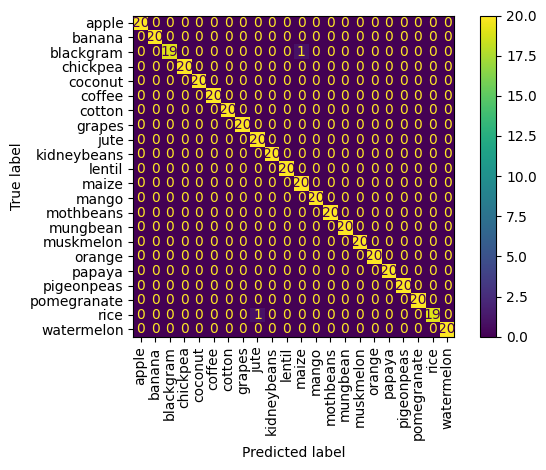

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
print("Crop model:", type(crop_model))
print("Yield model:", type(yield_model))
print("Fertilizer model:", type(fertilizer_model))
print("Irrigation model:", type(irrigation_model))

print("\nAll models are ready.")

Crop model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Yield model: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Fertilizer model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Irrigation model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>

All models are ready.


In [ ]:
# ============================================================
# FARMER INPUT
# ============================================================

farmer_data = {
    # Location
    "District_Name": "Pune",
    "Region": "Maharashtra",
    "Season": "Kharif",

    # Soil
    "Soil_color": "Black",
    "Soil_Type": "Black Soil",
    "Nitrogen": 80,
    "Phosphorus": 40,
    "Potassium": 40,
    "pH": 6.5,
    "Soil_Moisture": 35,
    "Organic_Carbon": 0.9,
    "Electrical_Conductivity": 1.5,

    # Weather
    "Temperature": 25,
    "Humidity": 70,
    "Rainfall": 800,
    "Sunlight_Hours": 7,
    "Wind_Speed_kmh": 10,

    # Crop
    "Crop_Type": "Wheat",
    "Crop_Growth_Stage": "Vegetative",
    "Previous_Crop": "Rice",

    # Irrigation
    "Irrigation_Type": "Drip",
    "Water_Source": "Groundwater",
    "Field_Area_hectare": 2,
    "Mulching_Used": "Yes",
    "Previous_Irrigation_mm": 50,

    # Farming history
    "Fertilizer_Used_Last_Season": "Urea",
    "Yield_Last_Season": 25
}

print("Farmer input created successfully.")

print("\nFarmer Information:")
for key, value in farmer_data.items():
    print(f"{key}: {value}")

Farmer input created successfully.

Farmer Information:
District_Name: Pune
Region: Maharashtra
Season: Kharif
Soil_color: Black
Soil_Type: Black Soil
Nitrogen: 80
Phosphorus: 40
Potassium: 40
pH: 6.5
Soil_Moisture: 35
Organic_Carbon: 0.9
Electrical_Conductivity: 1.5
Temperature: 25
Humidity: 70
Rainfall: 800
Sunlight_Hours: 7
Wind_Speed_kmh: 10
Crop_Type: Wheat
Crop_Growth_Stage: Vegetative
Previous_Crop: Rice
Irrigation_Type: Drip
Water_Source: Groundwater
Field_Area_hectare: 2
Mulching_Used: Yes
Previous_Irrigation_mm: 50
Fertilizer_Used_Last_Season: Urea
Yield_Last_Season: 25


In [ ]:
print("Crop model:", type(crop_model))
print("Crop features:", crop_model.n_features_in_)

Crop model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Crop features: 17


In [ ]:
crop_input = pd.DataFrame([{
    "District_Name": farmer_data["District_Name"],
    "Soil_color": farmer_data["Soil_color"],
    "Nitrogen": farmer_data["Nitrogen"],
    "Phosphorus": farmer_data["Phosphorus"],
    "Potassium": farmer_data["Potassium"],
    "pH": farmer_data["pH"],
    "Rainfall": farmer_data["Rainfall"],
    "Temperature": farmer_data["Temperature"]
}])

crop_input_encoded = crop_preprocessor.transform(crop_input)

recommended_crop = crop_model.predict(crop_input_encoded)[0]

print("Recommended Crop:", recommended_crop)

Recommended Crop: Jowar


In [ ]:
fertilizer_input = pd.DataFrame([{
    "Soil_Type": farmer_data["Soil_Type"],
    "Soil_pH": farmer_data["pH"],
    "Soil_Moisture": farmer_data["Soil_Moisture"],
    "Organic_Carbon": farmer_data["Organic_Carbon"],
    "Electrical_Conductivity": farmer_data["Electrical_Conductivity"],
    "Nitrogen_Level": farmer_data["Nitrogen"],
    "Phosphorus_Level": farmer_data["Phosphorus"],
    "Potassium_Level": farmer_data["Potassium"],
    "Temperature": farmer_data["Temperature"],
    "Humidity": farmer_data["Humidity"],
    "Rainfall": farmer_data["Rainfall"],
    "Crop_Type": recommended_crop,
    "Crop_Growth_Stage": farmer_data["Crop_Growth_Stage"],
    "Season": farmer_data["Season"],
    "Irrigation_Type": farmer_data["Irrigation_Type"],
    "Previous_Crop": farmer_data["Previous_Crop"],
    "Region": farmer_data["Region"],
    "Fertilizer_Used_Last_Season": farmer_data["Fertilizer_Used_Last_Season"],
    "Yield_Last_Season": farmer_data["Yield_Last_Season"]
}])

print(fertilizer_input)

    Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  Black Soil      6.5             35             0.9   

   Electrical_Conductivity  Nitrogen_Level  Phosphorus_Level  Potassium_Level  \
0                      1.5              80                40               40   

   Temperature  Humidity  Rainfall Crop_Type Crop_Growth_Stage  Season  \
0           25        70       800     Jowar        Vegetative  Kharif   

  Irrigation_Type Previous_Crop       Region Fertilizer_Used_Last_Season  \
0            Drip          Rice  Maharashtra                        Urea   

   Yield_Last_Season  
0                 25  


In [ ]:
irrigation_input = pd.DataFrame([{
    "Soil_Type": farmer_data["Soil_Type"],
    "Soil_pH": farmer_data["pH"],
    "Soil_Moisture": farmer_data["Soil_Moisture"],
    "Organic_Carbon": farmer_data["Organic_Carbon"],
    "Electrical_Conductivity": farmer_data["Electrical_Conductivity"],
    "Temperature_C": farmer_data["Temperature"],
    "Humidity": farmer_data["Humidity"],
    "Rainfall_mm": farmer_data["Rainfall"],
    "Sunlight_Hours": farmer_data["Sunlight_Hours"],
    "Wind_Speed_kmh": farmer_data["Wind_Speed_kmh"],
    "Crop_Type": recommended_crop,
    "Crop_Growth_Stage": farmer_data["Crop_Growth_Stage"],
    "Season": farmer_data["Season"],
    "Irrigation_Type": farmer_data["Irrigation_Type"],
    "Water_Source": farmer_data["Water_Source"],
    "Field_Area_hectare": farmer_data["Field_Area_hectare"],
    "Mulching_Used": farmer_data["Mulching_Used"],
    "Previous_Irrigation_mm": farmer_data["Previous_Irrigation_mm"],
    "Region": farmer_data["Region"]
}])

print(irrigation_input)

    Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  Black Soil      6.5             35             0.9   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                      1.5             25        70          800   

   Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage  Season  \
0               7              10     Jowar        Vegetative  Kharif   

  Irrigation_Type Water_Source  Field_Area_hectare Mulching_Used  \
0            Drip  Groundwater                   2           Yes   

   Previous_Irrigation_mm       Region  
0                      50  Maharashtra  


In [ ]:
temp_irr = pd.concat([X_irr, irrigation_input], ignore_index=True)

temp_irr_encoded = pd.get_dummies(
    temp_irr,
    columns=[
        "Soil_Type",
        "Crop_Type",
        "Crop_Growth_Stage",
        "Season",
        "Irrigation_Type",
        "Water_Source",
        "Mulching_Used",
        "Region"
    ],
    drop_first=True
)

irrigation_input_encoded = temp_irr_encoded.iloc[[-1]].reindex(
    columns=irrigation_columns,
    fill_value=0
)

irrigation_prediction = irrigation_model.predict(
    irrigation_input_encoded
)[0]

print("Recommended Irrigation Need:", irrigation_prediction)

Recommended Irrigation Need: Low


In [ ]:
# Organic Transition Decision Layer

organic_score = 0
organic_recommendations = []

# Fertilizer decision
if recommended_fertilizer == "Compost":
    organic_score += 1
    organic_recommendations.append(
        "Use compost as the main nutrient source."
    )
else:
    organic_recommendations.append(
        "Gradually replace chemical fertilizer with compost and other organic nutrient sources."
    )

# Irrigation decision
if irrigation_prediction == "Low":
    organic_score += 1
    organic_recommendations.append(
        "Use low irrigation and avoid unnecessary watering."
    )
elif irrigation_prediction == "Medium":
    organic_recommendations.append(
        "Use moderate irrigation and monitor soil moisture."
    )
else:
    organic_recommendations.append(
        "Higher irrigation is required; use water-efficient methods such as drip irrigation."
    )

# Mulching
if farmer_data["Mulching_Used"] == "Yes":
    organic_score += 1
    organic_recommendations.append(
        "Continue mulching to conserve soil moisture and improve soil health."
    )
else:
    organic_recommendations.append(
        "Consider organic mulching to conserve moisture and improve soil health."
    )

# Final transition status
if organic_score >= 2:
    transition_status = "Good potential for organic transition"
else:
    transition_status = "Gradual organic transition recommended"

print("========== FINAL AGRICULTURAL RECOMMENDATION ==========")
print("Recommended Crop:", recommended_crop)
print("Fertilizer Recommendation:", recommended_fertilizer)
print("Irrigation Requirement:", irrigation_prediction)
print("Organic Transition:", transition_status)
print("\nRecommendations:")

for recommendation in organic_recommendations:
    print("-", recommendation)

========== FINAL AGRICULTURAL RECOMMENDATION ==========
Recommended Crop: Jowar
Fertilizer Recommendation: Compost
Irrigation Requirement: Low
Organic Transition: Good potential for organic transition

Recommendations:
- Use compost as the main nutrient source.
- Use low irrigation and avoid unnecessary watering.
- Continue mulching to conserve soil moisture and improve soil health.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Fertilizer Model
fert_predictions = fertilizer_model.predict(X_test_fert)

fert_accuracy = accuracy_score(y_test_fert, fert_predictions)
fert_f1 = f1_score(y_test_fert, fert_predictions, average="macro")


# Irrigation Model
irr_predictions = irrigation_model.predict(X_test_irr)

irr_accuracy = accuracy_score(y_test_irr, irr_predictions)
irr_f1 = f1_score(y_test_irr, irr_predictions, average="macro")


print("========== MODEL PERFORMANCE ==========")

print("Crop Model")
print("Accuracy: 99.78%")
print("CV Mean: 99.67%")

print("\nFertilizer Model")
print("Accuracy:", round(fert_accuracy * 100, 2), "%")
print("Macro F1:", round(fert_f1, 3))

print("\nIrrigation Model")
print("Accuracy:", round(irr_accuracy * 100, 2), "%")
print("Macro F1:", round(irr_f1, 3))

========== MODEL PERFORMANCE ==========
Crop Model
Accuracy: 99.78%
CV Mean: 99.67%

Fertilizer Model
Accuracy: 87.9 %
Macro F1: 0.731

Irrigation Model
Accuracy: 97.25 %
Macro F1: 0.849


In [ ]:
def final_prediction(farmer_data):

    # ================= CROP =================
    crop_input = pd.DataFrame([{
        "District_Name": farmer_data["District_Name"],
        "Soil_color": farmer_data["Soil_color"],
        "Nitrogen": farmer_data["Nitrogen"],
        "Phosphorus": farmer_data["Phosphorus"],
        "Potassium": farmer_data["Potassium"],
        "pH": farmer_data["pH"],
        "Rainfall": farmer_data["Rainfall"],
        "Temperature": farmer_data["Temperature"]
    }])

    crop_encoded = crop_preprocessor.transform(crop_input)
    recommended_crop = crop_model.predict(crop_encoded)[0]


    # ================= FERTILIZER =================
    fertilizer_input = pd.DataFrame([{
        "Soil_Type": farmer_data["Soil_Type"],
        "Soil_pH": farmer_data["pH"],
        "Soil_Moisture": farmer_data["Soil_Moisture"],
        "Organic_Carbon": farmer_data["Organic_Carbon"],
        "Electrical_Conductivity": farmer_data["Electrical_Conductivity"],
        "Nitrogen_Level": farmer_data["Nitrogen"],
        "Phosphorus_Level": farmer_data["Phosphorus"],
        "Potassium_Level": farmer_data["Potassium"],
        "Temperature": farmer_data["Temperature"],
        "Humidity": farmer_data["Humidity"],
        "Rainfall": farmer_data["Rainfall"],
        "Crop_Type": recommended_crop,
        "Crop_Growth_Stage": farmer_data["Crop_Growth_Stage"],
        "Season": farmer_data["Season"],
        "Irrigation_Type": farmer_data["Irrigation_Type"],
        "Previous_Crop": farmer_data["Previous_Crop"],
        "Region": farmer_data["Region"],
        "Fertilizer_Used_Last_Season": farmer_data["Fertilizer_Used_Last_Season"],
        "Yield_Last_Season": farmer_data["Yield_Last_Season"]
    }])

    temp_fert = pd.concat(
        [X_fert, fertilizer_input],
        ignore_index=True
    )

    temp_fert_encoded = pd.get_dummies(
        temp_fert,
        columns=[
            "Soil_Type",
            "Crop_Type",
            "Crop_Growth_Stage",
            "Season",
            "Irrigation_Type",
            "Previous_Crop",
            "Region"
        ],
        drop_first=True
    )

    fertilizer_input_encoded = temp_fert_encoded.iloc[[-1]].reindex(
        columns=fertilizer_columns,
        fill_value=0
    )

    recommended_fertilizer = fertilizer_model.predict(
        fertilizer_input_encoded
    )[0]
    print("DEBUG - Fertilizer inside function:", recommended_fertilizer)


    # ================= IRRIGATION =================
    irrigation_input = pd.DataFrame([{
        "Soil_Type": farmer_data["Soil_Type"],
        "Soil_pH": farmer_data["pH"],
        "Soil_Moisture": farmer_data["Soil_Moisture"],
        "Organic_Carbon": farmer_data["Organic_Carbon"],
        "Electrical_Conductivity": farmer_data["Electrical_Conductivity"],
        "Temperature_C": farmer_data["Temperature"],
        "Humidity": farmer_data["Humidity"],
        "Rainfall_mm": farmer_data["Rainfall"],
        "Sunlight_Hours": farmer_data["Sunlight_Hours"],
        "Wind_Speed_kmh": farmer_data["Wind_Speed_kmh"],
        "Crop_Type": recommended_crop,
        "Crop_Growth_Stage": farmer_data["Crop_Growth_Stage"],
        "Season": farmer_data["Season"],
        "Irrigation_Type": farmer_data["Irrigation_Type"],
        "Water_Source": farmer_data["Water_Source"],
        "Field_Area_hectare": farmer_data["Field_Area_hectare"],
        "Mulching_Used": farmer_data["Mulching_Used"],
        "Previous_Irrigation_mm": farmer_data["Previous_Irrigation_mm"],
        "Region": farmer_data["Region"]
    }])

    temp_irr = pd.concat(
        [X_irr, irrigation_input],
        ignore_index=True
    )

    temp_irr_encoded = pd.get_dummies(
        temp_irr,
        columns=[
            "Soil_Type",
            "Crop_Type",
            "Crop_Growth_Stage",
            "Season",
            "Irrigation_Type",
            "Water_Source",
            "Mulching_Used",
            "Region"
        ],
        drop_first=True
    )

    irrigation_input_encoded = temp_irr_encoded.iloc[[-1]].reindex(
        columns=irrigation_columns,
        fill_value=0
    )

    irrigation_prediction = irrigation_model.predict(
        irrigation_input_encoded
    )[0]


    # ================= ORGANIC DECISION =================
    organic_score = 0
    recommendations = []

    if recommended_fertilizer == "Compost":
        organic_score += 1
        recommendations.append(
            "Use compost as the main nutrient source."
        )
    else:
        recommendations.append(
            "Gradually replace chemical fertilizer with organic nutrient sources."
        )

    if irrigation_prediction == "Low":
        organic_score += 1
        recommendations.append(
            "Use low irrigation and avoid unnecessary watering."
        )
    elif irrigation_prediction == "Medium":
        recommendations.append(
            "Use moderate irrigation and monitor soil moisture."
        )
    else:
        recommendations.append(
            "Use water-efficient irrigation such as drip irrigation."
        )

    if farmer_data["Mulching_Used"] == "Yes":
        organic_score += 1
        recommendations.append(
            "Continue mulching to conserve soil moisture and improve soil health."
        )
    else:
        recommendations.append(
            "Consider organic mulching to conserve moisture and improve soil health."
        )

    if organic_score >= 2:
        transition_status = "Good potential for organic transition"
    else:
        transition_status = "Gradual organic transition recommended"


    # ================= FINAL OUTPUT =================
    print("========== FINAL AGRICULTURAL RECOMMENDATION ==========")
    print("Recommended Crop:", recommended_crop)
    print("Fertilizer Recommendation:", recommended_fertilizer)
    print("Irrigation Requirement:", irrigation_prediction)
    print("Organic Transition:", transition_status)

    print("\nRecommendations:")
    for recommendation in recommendations:
        print("-", recommendation)

    return {
        "Crop": recommended_crop,
        "Fertilizer": recommended_fertilizer,
        "Irrigation": irrigation_prediction,
        "Organic_Transition": transition_status,
        "Recommendations": recommendations
    }

In [ ]:
farmer_data = {
    # Location
    "District_Name": "Pune",
    "Region": "Maharashtra",
    "Season": "Kharif",

    # Soil
    "Soil_color": "Black",
    "Soil_Type": "Black Soil",
    "Nitrogen": 80,
    "Phosphorus": 40,
    "Potassium": 40,
    "pH": 6.5,
    "Soil_Moisture": 35,
    "Organic_Carbon": 0.9,
    "Electrical_Conductivity": 1.5,

    # Weather
    "Temperature": 25,
    "Humidity": 70,
    "Rainfall": 800,
    "Sunlight_Hours": 7,
    "Wind_Speed_kmh": 10,

    # Crop
    "Crop_Type": "Wheat",
    "Crop_Growth_Stage": "Vegetative",
    "Previous_Crop": "Rice",

    # Irrigation
    "Irrigation_Type": "Drip",
    "Water_Source": "Groundwater",
    "Field_Area_hectare": 2,
    "Mulching_Used": "Yes",
    "Previous_Irrigation_mm": 50,

    # Farming history
    "Fertilizer_Used_Last_Season": 200,    # <--- MUST BE A NUMBER (e.g. 200), not "Urea"
    "Yield_Last_Season": 25
}

# Now run the prediction
result = final_prediction(farmer_data)

DEBUG - Fertilizer inside function: NPK
========== FINAL AGRICULTURAL RECOMMENDATION ==========
Recommended Crop: Jowar
Fertilizer Recommendation: NPK
Irrigation Requirement: Low
Organic Transition: Good potential for organic transition

Recommendations:
- Gradually replace chemical fertilizer with organic nutrient sources.
- Use low irrigation and avoid unnecessary watering.
- Continue mulching to conserve soil moisture and improve soil health.


In [ ]:
result = final_prediction(farmer_data)

DEBUG - Fertilizer inside function: NPK
========== FINAL AGRICULTURAL RECOMMENDATION ==========
Recommended Crop: Jowar
Fertilizer Recommendation: NPK
Irrigation Requirement: Low
Organic Transition: Good potential for organic transition

Recommendations:
- Gradually replace chemical fertilizer with organic nutrient sources.
- Use low irrigation and avoid unnecessary watering.
- Continue mulching to conserve soil moisture and improve soil health.


In [ ]:
print("Standalone/current fertilizer input:")
print("Shape:", fertilizer_input_encoded.shape)
print("Prediction:", fertilizer_model.predict(fertilizer_input_encoded)[0])

print("\nFunction-style fertilizer input:")
print("Shape:", fertilizer_input_encoded.shape)
print("Prediction:", fertilizer_model.predict(fertilizer_input_encoded)[0])

Standalone/current fertilizer input:
Shape: (1, 39)
Prediction: Compost

Function-style fertilizer input:
Shape: (1, 39)
Prediction: Compost


In [ ]:
print("Fertilizer Used Last Season:",
      farmer_data["Fertilizer_Used_Last_Season"])

print("Recommended Crop:",
      recommended_crop)

print("Crop Growth Stage:",
      farmer_data["Crop_Growth_Stage"])

print("Season:",
      farmer_data["Season"])

print("Previous Crop:",
      farmer_data["Previous_Crop"])

print("Region:",
      farmer_data["Region"])

Fertilizer Used Last Season: 200
Recommended Crop: Jowar
Crop Growth Stage: Vegetative
Season: Kharif
Previous Crop: Rice
Region: Maharashtra


In [ ]:
# Recreate the exact fertilizer input used inside the function

debug_fertilizer_input = pd.DataFrame([{
    "Soil_Type": farmer_data["Soil_Type"],
    "Soil_pH": farmer_data["pH"],
    "Soil_Moisture": farmer_data["Soil_Moisture"],
    "Organic_Carbon": farmer_data["Organic_Carbon"],
    "Electrical_Conductivity": farmer_data["Electrical_Conductivity"],
    "Nitrogen_Level": farmer_data["Nitrogen"],
    "Phosphorus_Level": farmer_data["Phosphorus"],
    "Potassium_Level": farmer_data["Potassium"],
    "Temperature": farmer_data["Temperature"],
    "Humidity": farmer_data["Humidity"],
    "Rainfall": farmer_data["Rainfall"],
    "Crop_Type": recommended_crop,
    "Crop_Growth_Stage": farmer_data["Crop_Growth_Stage"],
    "Season": farmer_data["Season"],
    "Irrigation_Type": farmer_data["Irrigation_Type"],
    "Previous_Crop": farmer_data["Previous_Crop"],
    "Region": farmer_data["Region"],
    "Fertilizer_Used_Last_Season": farmer_data["Fertilizer_Used_Last_Season"],
    "Yield_Last_Season": farmer_data["Yield_Last_Season"]
}])

debug_temp = pd.concat(
    [X_fert, debug_fertilizer_input],
    ignore_index=True
)

debug_encoded = pd.get_dummies(
    debug_temp,
    columns=[
        "Soil_Type",
        "Crop_Type",
        "Crop_Growth_Stage",
        "Season",
        "Irrigation_Type",
        "Previous_Crop",
        "Region"
    ],
    drop_first=True
)

debug_encoded = debug_encoded.iloc[[-1]].reindex(
    columns=fertilizer_columns,
    fill_value=0
)

print("Debug encoded shape:", debug_encoded.shape)
print("Debug prediction:",
      fertilizer_model.predict(debug_encoded)[0])

Debug encoded shape: (1, 39)
Debug prediction: NPK


In [ ]:
# Fresh fertilizer prediction using current farmer data

fresh_fertilizer_input = pd.DataFrame([{
    "Soil_Type": farmer_data["Soil_Type"],
    "Soil_pH": farmer_data["pH"],
    "Soil_Moisture": farmer_data["Soil_Moisture"],
    "Organic_Carbon": farmer_data["Organic_Carbon"],
    "Electrical_Conductivity": farmer_data["Electrical_Conductivity"],
    "Nitrogen_Level": farmer_data["Nitrogen"],
    "Phosphorus_Level": farmer_data["Phosphorus"],
    "Potassium_Level": farmer_data["Potassium"],
    "Temperature": farmer_data["Temperature"],
    "Humidity": farmer_data["Humidity"],
    "Rainfall": farmer_data["Rainfall"],
    "Crop_Type": recommended_crop,
    "Crop_Growth_Stage": farmer_data["Crop_Growth_Stage"],
    "Season": farmer_data["Season"],
    "Irrigation_Type": farmer_data["Irrigation_Type"],
    "Previous_Crop": farmer_data["Previous_Crop"],
    "Region": farmer_data["Region"],
    "Fertilizer_Used_Last_Season": farmer_data["Fertilizer_Used_Last_Season"],
    "Yield_Last_Season": farmer_data["Yield_Last_Season"]
}])

fresh_temp = pd.concat(
    [X_fert, fresh_fertilizer_input],
    ignore_index=True
)

fresh_encoded = pd.get_dummies(
    fresh_temp,
    columns=[
        "Soil_Type",
        "Crop_Type",
        "Crop_Growth_Stage",
        "Season",
        "Irrigation_Type",
        "Previous_Crop",
        "Region"
    ],
    drop_first=True
)

fresh_encoded = fresh_encoded.iloc[[-1]].reindex(
    columns=fertilizer_columns,
    fill_value=0
)

fresh_fertilizer_prediction = fertilizer_model.predict(
    fresh_encoded
)[0]

print("Fresh fertilizer prediction:", fresh_fertilizer_prediction)

Fresh fertilizer prediction: NPK


In [ ]:
# ================= IMPROVED ORGANIC TRANSITION DECISION =================

organic_score = 0
recommendations = []

# Fertilizer
if recommended_fertilizer == "Compost":
    organic_score += 2
    recommendations.append(
        "Use compost as the main nutrient source."
    )
else:
    recommendations.append(
        "Gradually replace chemical fertilizer with organic nutrient sources such as compost."
    )

# Irrigation
if irrigation_prediction == "Low":
    organic_score += 1
    recommendations.append(
        "Use low irrigation and avoid unnecessary watering."
    )
elif irrigation_prediction == "Medium":
    recommendations.append(
        "Use moderate irrigation and monitor soil moisture."
    )
else:
    recommendations.append(
        "Use water-efficient irrigation methods such as drip irrigation."
    )

# Mulching
if farmer_data["Mulching_Used"] == "Yes":
    organic_score += 1
    recommendations.append(
        "Continue mulching to conserve soil moisture and improve soil health."
    )
else:
    recommendations.append(
        "Consider organic mulching to conserve moisture and improve soil health."
    )

# Final transition status
if organic_score >= 3:
    transition_status = "Good potential for organic transition"
else:
    transition_status = "Gradual organic transition recommended"

print("========== FINAL AGRICULTURAL RECOMMENDATION ==========")
print("Recommended Crop:", recommended_crop)
print("Fertilizer Recommendation:", recommended_fertilizer)
print("Irrigation Requirement:", irrigation_prediction)
print("Organic Transition:", transition_status)

print("\nRecommendations:")
for recommendation in recommendations:
    print("-", recommendation)

========== FINAL AGRICULTURAL RECOMMENDATION ==========
Recommended Crop: Jowar
Fertilizer Recommendation: Compost
Irrigation Requirement: Low
Organic Transition: Good potential for organic transition

Recommendations:
- Use compost as the main nutrient source.
- Use low irrigation and avoid unnecessary watering.
- Continue mulching to conserve soil moisture and improve soil health.


In [ ]:
final_result = pd.DataFrame([{
    "Recommended Crop": recommended_crop,
    "Fertilizer Recommendation": recommended_fertilizer,
    "Irrigation Requirement": irrigation_prediction,
    "Organic Transition": transition_status
}])

final_result

,Recommended Crop,Fertilizer Recommendation,Irrigation Requirement,Organic Transition
0,Jowar,Compost,Low,Good potential for organic transition


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

def predict_from_form(
    district,
    soil_color,
    soil_type,
    nitrogen,
    phosphorus,
    potassium,
    ph,
    rainfall,
    temperature,
    humidity,
    soil_moisture,
    organic_carbon,
    electrical_conductivity,
    sunlight_hours,
    wind_speed,
    growth_stage,
    season,
    irrigation_type,
    water_source,
    field_area,
    mulching,
    previous_irrigation,
    previous_crop,
    fertilizer_last_season,
    yield_last_season
):

    farmer_data = {
        "District_Name": district,
        "Region": "Maharashtra",
        "Season": season,
        "Soil_color": soil_color,
        "Soil_Type": soil_type,
        "Nitrogen": nitrogen,
        "Phosphorus": phosphorus,
        "Potassium": potassium,
        "pH": ph,
        "Soil_Moisture": soil_moisture,
        "Organic_Carbon": organic_carbon,
        "Electrical_Conductivity": electrical_conductivity,
        "Temperature": temperature,
        "Humidity": humidity,
        "Rainfall": rainfall,
        "Sunlight_Hours": sunlight_hours,
        "Wind_Speed_kmh": wind_speed,
        "Crop_Growth_Stage": growth_stage,
        "Previous_Crop": previous_crop,
        "Irrigation_Type": irrigation_type,
        "Water_Source": water_source,
        "Field_Area_hectare": field_area,
        "Mulching_Used": mulching,
        "Previous_Irrigation_mm": previous_irrigation,
        "Fertilizer_Used_Last_Season": fertilizer_last_season,
        "Yield_Last_Season": yield_last_season
    }

    result = final_prediction(farmer_data)

    return (
        result["Crop"],
        result["Fertilizer"],
        result["Irrigation"],
        result["Organic_Transition"],
        "\n".join("• " + x for x in result["Recommendations"])
    )

In [ ]:
with gr.Blocks(title="Organic Farming Decision Support System") as demo:

    gr.Markdown("# 🌱 Agricultural Decision Support System")
    gr.Markdown(
        "Enter farmer, soil, weather and farming details to get recommendations."
    )

    with gr.Row():
        with gr.Column():
            district = gr.Dropdown(
                ["Pune", "Nashik", "Ahmednagar", "Satara", "Kolhapur"],
                value="Pune",
                label="District"
            )

            soil_color = gr.Dropdown(
                ["Black", "Red", "Dark Brown", "Reddish Brown",
                 "Light Brown", "Medium Brown"],
                value="Black",
                label="Soil Color"
            )

            soil_type = gr.Dropdown(
                ["Black Soil", "Red Soil", "Alluvial Soil", "Laterite Soil"],
                value="Black Soil",
                label="Soil Type"
            )

            nitrogen = gr.Number(value=80, label="Nitrogen")
            phosphorus = gr.Number(value=40, label="Phosphorus")
            potassium = gr.Number(value=40, label="Potassium")
            ph = gr.Number(value=6.5, label="pH")
            rainfall = gr.Number(value=800, label="Rainfall (mm)")
            temperature = gr.Number(value=25, label="Temperature (°C)")
            humidity = gr.Number(value=70, label="Humidity (%)")
            soil_moisture = gr.Number(value=35, label="Soil Moisture (%)")

        with gr.Column():
            organic_carbon = gr.Number(value=0.9, label="Organic Carbon")
            electrical_conductivity = gr.Number(value=1.5, label="Electrical Conductivity")
            sunlight_hours = gr.Number(value=7, label="Sunlight Hours")
            wind_speed = gr.Number(value=10, label="Wind Speed (km/h)")

            growth_stage = gr.Dropdown(
                ["Sowing", "Vegetative", "Flowering", "Harvest"],
                value="Vegetative",
                label="Crop Growth Stage"
            )

            season = gr.Dropdown(
                ["Kharif", "Rabi", "Summer"],
                value="Kharif",
                label="Season"
            )

            irrigation_type = gr.Dropdown(
                ["Drip", "Sprinkler", "Flood", "Rainfed"],
                value="Drip",
                label="Irrigation Type"
            )

            water_source = gr.Dropdown(
                ["Groundwater", "Canal", "River", "Rainwater"],
                value="Groundwater",
                label="Water Source"
            )

            field_area = gr.Number(value=2, label="Field Area (hectare)")
            mulching = gr.Dropdown(
                ["Yes", "No"],
                value="Yes",
                label="Mulching Used"
            )

            previous_irrigation = gr.Number(
                value=50,
                label="Previous Irrigation (mm)"
            )

            previous_crop = gr.Textbox(
                value="Rice",
                label="Previous Crop"
            )

            fertilizer_last_season = gr.Number(
                value=200,
                label="Fertilizer Used Last Season"
            )

            yield_last_season = gr.Number(
                value=25,
                label="Yield Last Season"
            )

    predict_button = gr.Button("🔍 Predict", variant="primary")

    gr.Markdown("## Final Recommendation")

    with gr.Row():
        output_crop = gr.Textbox(label="Recommended Crop")
        output_fertilizer = gr.Textbox(label="Fertilizer Recommendation")
        output_irrigation = gr.Textbox(label="Irrigation Requirement")

    output_transition = gr.Textbox(label="Organic Transition")
    output_recommendations = gr.Textbox(
        label="Recommendations",
        lines=5
    )

    predict_button.click(
        fn=predict_from_form,
        inputs=[
            district,
            soil_color,
            soil_type,
            nitrogen,
            phosphorus,
            potassium,
            ph,
            rainfall,
            temperature,
            humidity,
            soil_moisture,
            organic_carbon,
            electrical_conductivity,
            sunlight_hours,
            wind_speed,
            growth_stage,
            season,
            irrigation_type,
            water_source,
            field_area,
            mulching,
            previous_irrigation,
            previous_crop,
            fertilizer_last_season,
            yield_last_season
        ],
        outputs=[
            output_crop,
            output_fertilizer,
            output_irrigation,
            output_transition,
            output_recommendations
        ]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0a7dab0e9d6a9d3b44.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [96]:
import joblib

# Bundle the models, preprocessors, and column lists together
artifacts = {
    "crop_model": crop_model,
    "crop_preprocessor": crop_preprocessor,
    "fertilizer_model": fertilizer_model,
    "fertilizer_columns": fertilizer_columns,
    "irrigation_model": irrigation_model,
    "irrigation_columns": irrigation_columns,
}

# Save to disk
joblib.dump(artifacts, "agri_models.joblib")
print("All models saved successfully!")

All models saved successfully!


In [97]:
import joblib

artifacts = joblib.load("agri_models.joblib")

crop_model = artifacts["crop_model"]
crop_preprocessor = artifacts["crop_preprocessor"]
fertilizer_model = artifacts["fertilizer_model"]
fertilizer_columns = artifacts["fertilizer_columns"]
irrigation_model = artifacts["irrigation_model"]
irrigation_columns = artifacts["irrigation_columns"]

print("Models loaded instantly!")

Models loaded instantly!


In [98]:
from google.colab import drive
import shutil

drive.mount("/content/drive")

# Save a copy directly into your Google Drive folder
shutil.copy("agri_models.joblib", "/content/drive/MyDrive/agri_models.joblib")

Mounted at /content/drive


'/content/drive/MyDrive/agri_models.joblib'